#Amit pawar
#PRN:25070126501
#we using Medical_Risk_Classification

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

import warnings
warnings.filterwarnings('ignore')

In [4]:
import pandas as pd
dataset = pd.read_csv('/content/Medical_Risk_Classification.csv')
dataset.head(20)

,Biomarker_A,Biomarker_B,BMI,Age,Smoking_Status,Family_History,BMI_Squared,Age_Normalized,High_Risk
0,1.572821,0.719531,20.921853,76.852031,Non-Smoker,Yes,437.723931,0.960650,1
1,0.421854,1.924399,19.006796,41.350755,Current,No,361.258302,0.516884,1
2,3.425030,5.205850,19.791748,34.992573,Non-Smoker,Yes,391.713285,0.437407,1
3,3.538766,1.395408,21.139071,56.973044,Current,Yes,446.860330,0.712163,1
4,1.799962,3.646175,23.798603,49.932369,Non-Smoker,No,566.373523,0.624155,0
5,0.383617,2.416027,27.240174,79.351134,Former,Yes,742.027079,0.991889,1
6,2.131489,1.247062,30.098595,47.741707,Non-Smoker,Yes,905.925421,0.596771,1
7,2.211677,4.880441,21.585765,24.459893,Non-Smoker,Yes,465.945238,0.305749,1
8,3.343354,4.456988,29.432881,78.642144,Former,No,866.294476,0.983027,1
9,1.577082,3.969546,29.972404,70.615217,Former,No,898.345018,0.882690,1


In [5]:
dataset.shape

(1000, 9)

In [20]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Biomarker_A     1000 non-null   float64
 1   Biomarker_B     1000 non-null   float64
 2   BMI             1000 non-null   float64
 3   Age             1000 non-null   float64
 4   Smoking_Status  1000 non-null   object 
 5   Family_History  1000 non-null   object 
 6   BMI_Squared     1000 non-null   float64
 7   Age_Normalized  1000 non-null   float64
 8   High_Risk       1000 non-null   int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 70.4+ KB


# DATA PREPROSSING
we encoder 'gender' using LabelEncodeing

In [11]:
# Separate features (X) and target (y)
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1].values

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply Label Encoding to categorical columns
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le # Store encoder if needed later for inverse transform or new data

# Convert X back to numpy array for consistency with previous x_train/x_test usage
x = X.values

# The import for train_test_split is already handled in the initial imports cell, if not, it would be here.
# from sklearn.model_selection import train_test_split

#Train-Test Split

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=42, stratify=y)

#Baseline Model

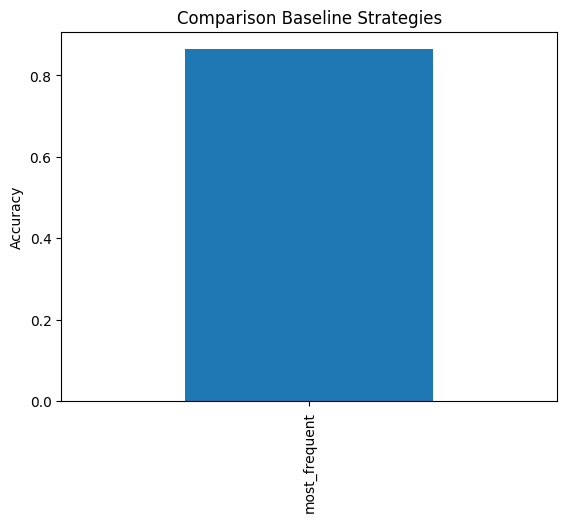

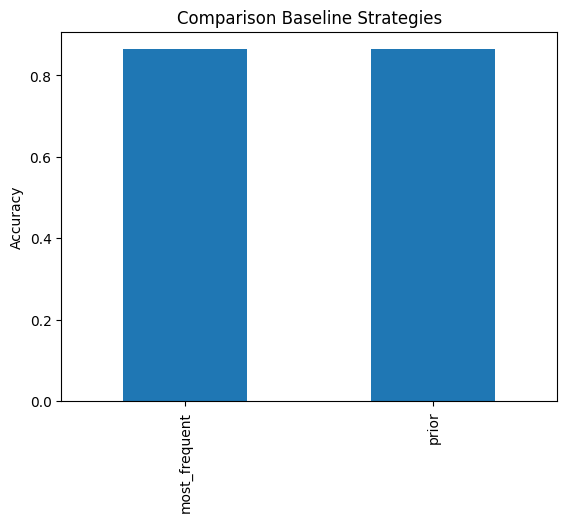

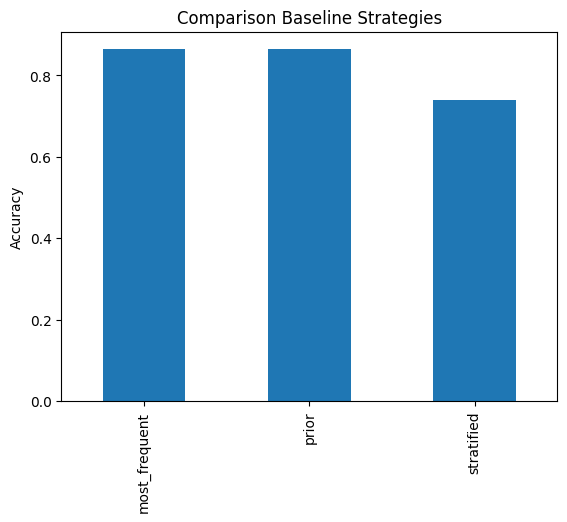

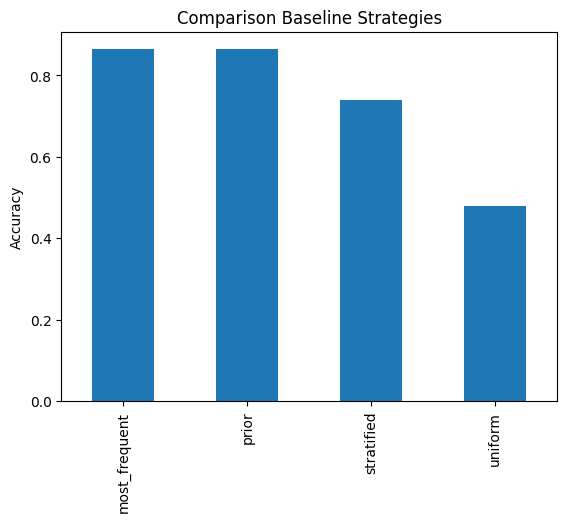

In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

stratified = ["most_frequent" , "prior" , "stratified" , "uniform"]
results = {}

for strategy in stratified:
  model = DummyClassifier(strategy=strategy , random_state=42)
  model.fit(x_train,y_train)
  results[strategy] = accuracy_score(y_test,model.predict(x_test))


  pd.Series(results).plot(kind="bar")
  plt.ylabel("Accuracy")
  plt.title("Comparison Baseline Strategies")
  plt.show()

# Applying Decision Tree

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

tree = DecisionTreeClassifier(random_state=42)
tree.fit(x_train,y_train)

y_pred = tree.predict(x_test)
print("Test Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Test Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.81      0.74      0.77        34
           1       0.96      0.97      0.97       216

    accuracy                           0.94       250
   macro avg       0.88      0.85      0.87       250
weighted avg       0.94      0.94      0.94       250



#Visualize Tree

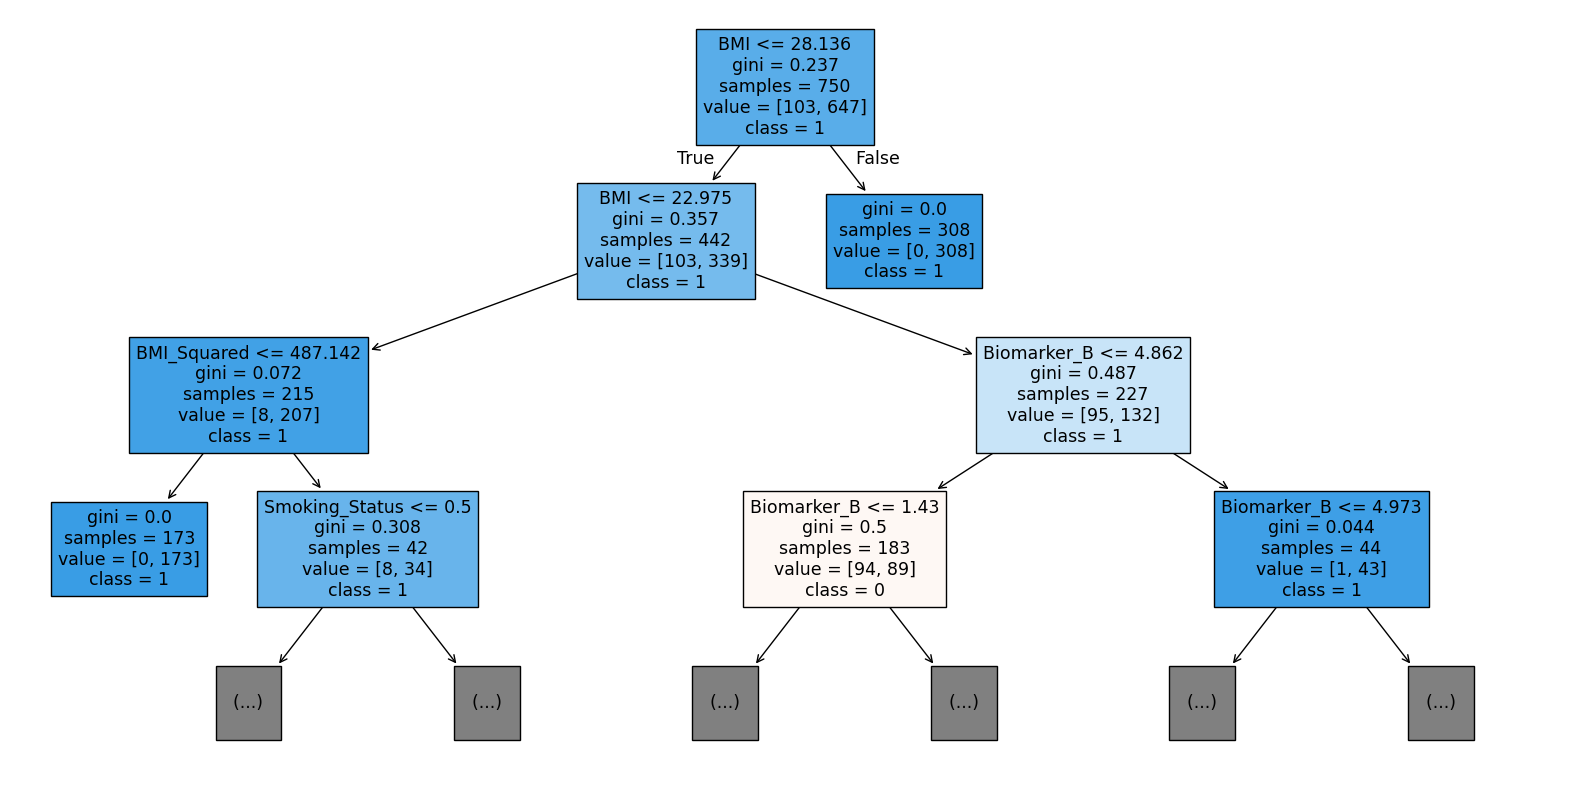

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(tree,max_depth = 3,filled=True,feature_names=X.columns.tolist(),
          class_names=tree.classes_.astype(str))
plt.show()

#Gini Accuracy and Entropy Accurcy

In [21]:
tree_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

tree_gini.fit(x_train, y_train)
tree_entropy.fit(x_train, y_train)

print("Gini Accuracy:", accuracy_score(y_test, tree_gini.predict(x_test)))
print("Entropy Accuracy:", accuracy_score(y_test, tree_entropy.predict(x_test)))

Gini Accuracy: 0.852
Entropy Accuracy: 0.864


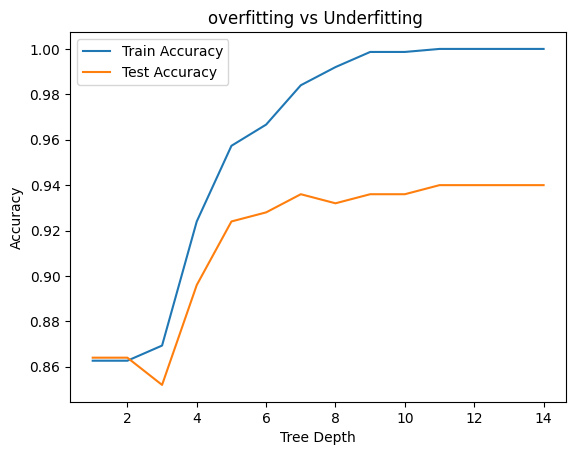

In [22]:
depths = range(1,15)
train_acc, test_acc = [],[]

for d in depths:
  model = DecisionTreeClassifier(max_depth=d, random_state=42)
  model.fit(x_train, y_train)
  train_acc.append(model.score(x_train, y_train))
  test_acc.append(model.score(x_test,y_test))

plt.figure()
plt.plot(depths, train_acc, label='Train Accuracy')
plt.plot(depths, test_acc, label='Test Accuracy')
plt.xlabel("Tree Depth")
plt.ylabel('Accuracy')
plt.legend()
plt.title("overfitting vs Underfitting ")
plt.show()

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "max_depth": [None, 3,5,7,10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring="accuracy")
grid.fit(x_train, y_train)
grid.best_params_

{'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5}

#feature Importance

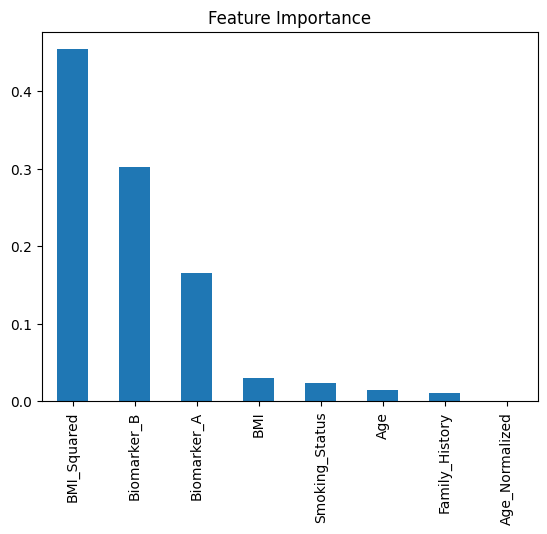

In [25]:
best_tree = grid.best_estimator_
importances = best_tree.feature_importances_

feature = X.columns.tolist()

pd.Series(importances, index=feature).sort_values(ascending=False).plot(kind="bar")
plt.title("Feature Importance")
plt.show()

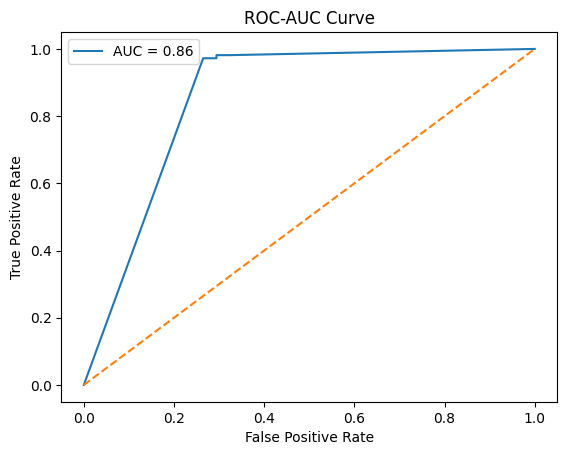

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = best_tree.predict_proba(x_test)[:, 1]
fpr , tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()